# 010.Simple Linear Regression

## Univariate Linear Regression (단변수 선형회귀)

In [ ]:
# scikit-learn 라이브러리 설치 (필요시 주석 해제)
#pip install scikit-learn

In [ ]:
# 필요한 라이브러리 import
import matplotlib.pyplot as plt  # 그래프 시각화
import numpy as np  # 수치 연산
from sklearn import datasets, linear_model  # 데이터셋 및 선형회귀 모델
from sklearn.metrics import mean_squared_error, r2_score  # 평가 지표
from sklearn.model_selection import train_test_split  # 데이터 분할
import pandas as pd  # 데이터프레임 처리

In [ ]:
# 당뇨병 데이터셋 로드
# 나이, 성별, 체질량지수, 혈압, 6가지 혈청 수치  --> already scaled (이미 정규화됨)
diabetes = datasets.load_diabetes()
# 특성 이름 확인
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [ ]:
# 데이터셋의 크기 확인 (샘플 수, 특성 수)
diabetes.data.shape

(442, 10)

In [ ]:
# 데이터의 처음 5개 샘플 확인
diabetes.data[:5]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034],
       [-0.08906294, -0.04464164, -0.01159501, -0.03665608,  0.01219057,
         0.02499059, -0.03603757,  0.03430886,  0.02268774, -0.00936191],
       [ 0.00538306, -0.04464164, -0.03638469,  0.02187239,  0.00393485,
         0.01559614,  0.00814208, -0.00259226, -0.03198764, -0.04664087]])

In [ ]:
# 1년 뒤 측정한 당뇨병의 진행률 - target(label, 목표 변수)
# 처음 5개 샘플의 타겟 값 확인
diabetes.target[:5]

array([151.,  75., 141., 206., 135.])

In [ ]:
# 데이터를 pandas DataFrame으로 변환
df_diab  = pd.DataFrame(data=diabetes.data, 
                        columns=diabetes.feature_names)

In [ ]:
df_diab.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## univariate linear regression data 생성

In [ ]:
# 단변수 선형회귀를 위해 하나의 특성만 사용 (BMI)
# reshape(-1, 1)을 사용하여 2차원 배열로 변환 (sklearn 요구사항)
diabetes_X = df_diab['bmi'].values.reshape(-1, 1)

In [ ]:
# 학습/테스트 데이터셋 분할 (train_test_split 사용)
# test_size=0.2: 전체 데이터의 20%를 테스트 세트로 사용
# random_state=42: 재현 가능한 결과를 위한 랜덤 시드 설정
diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = train_test_split(
    diabetes_X, diabetes.target, test_size=0.2, random_state=42
)

## sklearn model 이용

In [ ]:
# 선형회귀 모델 객체 생성
regr = linear_model.LinearRegression()

In [15]:
from sklearn import set_config

# 파이프라인이나 모델 객체를 출력할 때,
# 변경된 파라미터만 출력하지 않고 모든 파라미터를 전체 출력하도록 설정
set_config(print_changed_only=False)

In [ ]:
# 학습 세트를 이용하여 모델 훈련
regr.fit(diabetes_X_train, diabetes_y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# 회귀 계수와 절편 출력
# coef_: 회귀 계수 (기울기)
# intercept_: 절편 (y절편)
print('Coefficients: \n', regr.coef_)
print('Intercept: \n', regr.intercept_)

Coefficients: 
 [938.23786125]
Intercept: 
 152.91886182616113


In [ ]:
# 테스트 세트에 대한 예측 수행
y_pred = regr.predict(diabetes_X_test)

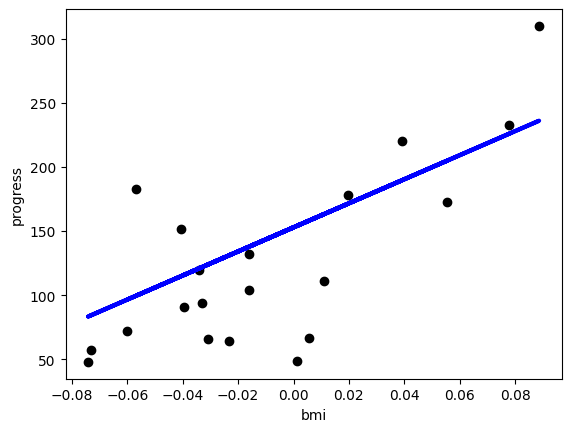

In [ ]:
# 당뇨병 테스트 데이터의 산점도를 그림
plt.scatter(diabetes_X_test, diabetes_y_test, color='black')

# 당뇨병 테스트 데이터에 대한 예측 값을 선 그래프로 그림
plt.plot(diabetes_X_test, y_pred, color='blue', linewidth=3)

# x축 라벨을 'bmi'로 설정
plt.xlabel('bmi')

# y축 라벨을 'progress'로 설정
plt.ylabel('progress')

plt.show()

## R2 계산

In [ ]:
# 결정계수(R²) 계산 및 출력
# R²는 모델의 설명력을 나타내며, 1에 가까울수록 좋은 모델
print("결정계수 : {:.2f}".format(r2_score(diabetes_y_test, y_pred)))

결정계수 : 0.47


## Multivariate Linear Regression (다변수 선형회귀)

모든 특성(10개)을 이용한 다변수 선형회귀

In [ ]:
# 데이터프레임의 처음 5개 행 확인
df_diab.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
# 다변수 선형회귀를 위해 모든 특성 사용 (10개 특성)
diabetes_X = df_diab.values

In [ ]:
# 데이터의 형태 확인 (샘플 수, 특성 수)
diabetes_X.shape

(442, 10)

In [ ]:
# 학습/테스트 데이터셋 분할 (train_test_split 사용)
# test_size=0.2: 전체 데이터의 20%를 테스트 세트로 사용
# random_state=42: 재현 가능한 결과를 위한 랜덤 시드 설정
diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = train_test_split(
    diabetes_X, diabetes.target, test_size=0.2, random_state=42
)

In [ ]:
# 선형회귀 모델 객체 생성
regr = linear_model.LinearRegression()

In [ ]:
# 학습 세트를 이용하여 모델 훈련
regr.fit(diabetes_X_train, diabetes_y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# 테스트 세트에 대한 예측 수행
diabetes_y_pred = regr.predict(diabetes_X_test)

In [ ]:
# 결정계수(R²) 계산 및 출력
# R²는 모델의 설명력을 나타내며, 1에 가까울수록 좋은 모델
print("결정계수: {:.2f}".format(r2_score(diabetes_y_test, diabetes_y_pred)))

결정계수: 0.59
